## Lab assignment 02

### Neural Machine Translation in the wild
In the third homework you are supposed to get the best translation you can for the RU-EN translation task.

Basic approach using RNNs as encoder and decoder is implemented for you.

Your ultimate task is to use the techniques we've covered, e.g.

* Optimization enhancements (e.g. learning rate decay)

* Transformer/CNN/<whatever you select> encoder (with or without positional encoding)

* attention/self-attention mechanism (**highly recommended**)

* custom tokenization (BPE units, other subword approaches)

to improve the translation quality.

--------

* __Please use at least three different approaches/models and compare them (translation quality/complexity/training and evaluation time).__

* Write down some summary on your experiments and illustrate it with convergence plots/metrics and your thoughts. Just like you would approach a real problem.

In [1]:
# You might need to install the libraries below. Do it in the desired environment
# if you are working locally.
! pip  install subword-nmt
! pip install nltk
! pip install torchtext


   -------------------- ------------------- 1/2 [subword-nmt]
   ---------------------------------------- 2/2 [subword-nmt]




[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.6 MB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 4.9 MB/s  0:00:00

   ---------------------------------------- 0/3 [regex]
   ------------- -------------------------- 1/3 [click]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   ------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------- ----------------------- 0.8/2.0 MB 6.7 MB/s eta 0:00:01
   ---------------------------------------- 2.0/2.0 MB 9.0 MB/s  0:00:00
   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   - -------------------------------------- 3.4/114.6 MB 16.7 MB/s eta 0:00:07
   -- ------------------------------------- 6.3/114.6 MB 14.3 MB/s eta 0:00:08
   --- ------------------------------------ 8.9/114.6 MB 14.6 MB/s eta 0:00:08
   ---- ----------------------------------- 11.5/114.6 MB 13.6 MB/s eta 0:00:08
   ---- ----------------------------------- 13.9/114.6 MB 13.0 MB/s eta 0:00:08
   ----- ---------------------------------- 16.0/114.6 MB 12.6 MB/s eta 0:00:08
   ------ --------------------------------- 18.6/114.6 MB 12.5 MB/s eta 0:00:08
   ------- -------------------------------- 21.0/114.6 MB 12.3 MB/s eta 0:00:08
   -------- ------------------------------- 23.1/114.6 MB 12.0 MB/s eta 0:


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
! pip install tokenizers

   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.7 MB ? eta -:--:--
   ------------------- -------------------- 1.3/2.7 MB 3.9 MB/s eta 0:00:01
   ---------------------------------- ----- 2.4/2.7 MB 4.3 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 4.1 MB/s  0:00:00
   ---------------------------------------- 0.0/637.4 kB ? eta -:--:--
   ---------------------------------------- 637.4/637.4 kB 4.8 MB/s  0:00:00
   ---------------------------------------- 0.0/3.7 MB ? eta -:--:--
   ----------------- ---------------------- 1.6/3.7 MB 8.4 MB/s eta 0:00:01
   ---------------------------------- ----- 3.1/3.7 MB 8.0 MB/s eta 0:00:01
   ---------------------------------------- 3.7/3.7 MB 7.8 MB/s  0:00:00

   ---- ----------------------------------- 1/9 [mdurl]
   ------------- -------------------------- 3/9 [annotated-doc]
   ----------------- ---------------------- 4/9 [markdown-it-py]
   ------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# Thanks to YSDA NLP course team for the data
# (who thanks tilda and deephack teams for the data in their turn)

import os
path_to_data = 'data.txt'
if not os.path.exists(path_to_data):
    print("Dataset not found locally. Downloading from github.")
    !wget https://raw.githubusercontent.com/neychev/made_nlp_course/master/datasets/Machine_translation_EN_RU/data.txt -nc
    path_to_data = './data.txt'

#### Grading criteria

**100%**
- implementation of at least 3 model improvements over baseline
- threshold of 27 BLEU on test corpus
- experimental results and conclusions in human-readable format :)

**70%**
- implementation of at least 2 model improvements over baseline
- threshold of 25 BLEU on test corpus
- experimental results and conclusions in human-readable format :)

**30%**
- implementation of at least 1 model improvement over baseline
- threshold of 21 BLEU on test corpus
- experimental results and conclusions in human-readable format :)


------

#### **Note: Please do not use pretrained machine translation / BERT / LLM checkpoints. All such solutions will be graded at 30% pts.**


### Warning! The code below is deeeeeeeply deprecated and is is provided only as simple guide.
We suggest you to stick to most recent pipelines here, e.g. by Huggingface:
* Example notebook: [link](https://github.com/huggingface/notebooks/blob/main/examples/translation.ipynb)
* Converting your own dataset to specific format: [link](https://discuss.huggingface.co/t/correct-way-to-create-a-dataset-from-a-csv-file/15686/15)

In [6]:
# Читаем файл — там TSV формат: English \t Russian
en_sentences = []
ru_sentences = []

with open(path_to_data, encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) == 2:
            en_sentences.append(parts[0])
            ru_sentences.append(parts[1])

print(f"Всего пар: {len(en_sentences)}")
print(f"Пример EN: {en_sentences[0]}")
print(f"Пример RU: {ru_sentences[0]}")

Всего пар: 50000
Пример EN: Cordelia Hotel is situated in Tbilisi, a 3-minute walk away from Saint Trinity Church.
Пример RU: Отель Cordelia расположен в Тбилиси, в 3 минутах ходьбы от Свято-Троицкого собора.


In [9]:
!pip uninstall torch -y
!pip install torch --index-url https://download.pytorch.org/whl/cu128

Found existing installation: torch 2.11.0
Uninstalling torch-2.11.0:
  Successfully uninstalled torch-2.11.0


You can safely remove it manually.


Looking in indexes: https://download.pytorch.org/whl/cu128
   ---------------------------------------- 0.0/2.8 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 GB 5.6 MB/s eta 0:08:14
   ---------------------------------------- 0.0/2.8 GB 14.3 MB/s eta 0:03:13
   ---------------------------------------- 0.0/2.8 GB 18.8 MB/s eta 0:02:27
   ---------------------------------------- 0.0/2.8 GB 21.4 MB/s eta 0:02:08
   ---------------------------------------- 0.0/2.8 GB 20.6 MB/s eta 0:02:13
   ---------------------------------------- 0.0/2.8 GB 21.5 MB/s eta 0:02:08
   ---------------------------------------- 0.0/2.8 GB 22.0 MB/s eta 0:02:04
    --------------------------------------- 0.0/2.8 GB 23.2 MB/s eta 0:01:58
    --------------------------------------- 0.0/2.8 GB 23.9 MB/s eta 0:01:54
    --------------------------------------- 0.0/2.8 GB 24.1 MB/s eta 0:01:53
    --------------------------------------- 0.1/2.8 GB 23.1 MB/s eta 0:01:58
    ----------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import ByteLevel
from tokenizers.decoders import ByteLevel as ByteLevelDecoder

# Создаём токенизатор
tokenizer = Tokenizer(BPE(unk_token="<unk>"))

# ByteLevel корректно помечает пробелы (Ġ в начале токена)
tokenizer.pre_tokenizer = ByteLevel()
tokenizer.decoder = ByteLevelDecoder()

trainer = BpeTrainer(
    vocab_size=8000,
    min_frequency=2,
    special_tokens=["<unk>", "<pad>", "<sos>", "<eos>"]
)

all_sentences = ru_sentences + en_sentences
tokenizer.train_from_iterator(all_sentences, trainer)

print(f"Размер словаря: {tokenizer.get_vocab_size()}")

# Проверяем
test_enc = tokenizer.encode("Various other tram lines stop right in front of the hotel")
print(f"Токены: {test_enc.tokens}")
print(f"Декод: {tokenizer.decode(test_enc.ids)}")

Размер словаря: 8000
Токены: ['ĠVarious', 'Ġother', 'Ġtram', 'Ġlin', 'es', 'Ġstop', 'Ġright', 'Ġin', 'Ġfront', 'Ġof', 'Ġthe', 'Ġhotel']
Декод:  Various other tram lines stop right in front of the hotel


### Main part
__Here comes the preprocessing. Do not hesitate to use BPE or more complex preprocessing ;)__

In [1]:
test = tokenizer.encode("предоставляется предоставляют предоставил")
print(f"Токены: {test.tokens}")

NameError: name 'tokenizer' is not defined

In [12]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import random

In [33]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [13]:
# Фиксируем seed для воспроизводимости
random.seed(42)
torch.manual_seed(42)

In [34]:
# Перемешиваем и делим данные
pairs = list(zip(ru_sentences, en_sentences))
random.shuffle(pairs)

In [35]:
n = len(pairs)
train_pairs = pairs[:int(0.8 * n)]   # 40000
val_pairs   = pairs[int(0.8 * n):int(0.95 * n)]  # 7500
test_pairs  = pairs[int(0.95 * n):]  # 2500

print(f"Train: {len(train_pairs)}, Val: {len(val_pairs)}, Test: {len(test_pairs)}")

Train: 40000, Val: 7500, Test: 2500


In [36]:
PAD_IDX = tokenizer.get_vocab()["<pad>"]
SOS_IDX = tokenizer.get_vocab()["<sos>"]
EOS_IDX = tokenizer.get_vocab()["<eos>"]

class TranslationDataset(Dataset):
    def __init__(self, pairs, tokenizer, max_len=50):
        self.pairs = pairs
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        ru, en = self.pairs[idx]

        # Токенизируем
        src_ids = self.tokenizer.encode(ru).ids[:self.max_len]
        trg_ids = self.tokenizer.encode(en).ids[:self.max_len]

        # Добавляем <sos> и <eos>
        src = [SOS_IDX] + src_ids + [EOS_IDX]
        trg = [SOS_IDX] + trg_ids + [EOS_IDX]

        return torch.tensor(src), torch.tensor(trg)


def collate_fn(batch):
    """Паддинг батча до одинаковой длины"""
    src_batch, trg_batch = zip(*batch)
    src_batch = torch.nn.utils.rnn.pad_sequence(
        src_batch, padding_value=PAD_IDX, batch_first=False
    )
    trg_batch = torch.nn.utils.rnn.pad_sequence(
        trg_batch, padding_value=PAD_IDX, batch_first=False
    )
    return src_batch, trg_batch


BATCH_SIZE = 128

train_dataset = TranslationDataset(train_pairs, tokenizer)
val_dataset   = TranslationDataset(val_pairs,   tokenizer)
test_dataset  = TranslationDataset(test_pairs,  tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn)

# Проверяем один батч
src, trg = next(iter(train_loader))
print(f"src shape: {src.shape}")  # [seq_len, batch_size]
print(f"trg shape: {trg.shape}")

src shape: torch.Size([52, 128])
trg shape: torch.Size([48, 128])


Here are tokens from original (RU) corpus:

Let's check the length distributions:

### Model side
__Here comes simple pipeline of NMT model learning. It almost copies the week02 practice__

In [38]:
import torch
import torch.nn as nn

class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.rnn = nn.LSTM(emb_dim, hid_dim, n_layers, dropout=dropout)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src = [seq_len, batch_size]
        embedded = self.dropout(self.embedding(src))
        # embedded = [seq_len, batch_size, emb_dim]

        outputs, (hidden, cell) = self.rnn(embedded)
        # outputs = [seq_len, batch_size, hid_dim]  ← все промежуточные состояния
        # hidden  = [n_layers, batch_size, hid_dim] ← последнее состояние

        return outputs, hidden, cell

In [21]:
class Attention(nn.Module):
    def __init__(self, hid_dim):
        super().__init__()
        # принимает [decoder_hidden, encoder_output] и выдаёт score
        self.attn = nn.Linear(hid_dim * 2, hid_dim)
        self.v = nn.Linear(hid_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden          = [batch_size, hid_dim]  (последний слой декодера)
        # encoder_outputs = [src_len, batch_size, hid_dim]

        src_len = encoder_outputs.shape[0]

        # 1. Повторяем hidden для каждого слова источника
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)
        # hidden = [batch_size, src_len, hid_dim]

        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        # encoder_outputs = [batch_size, src_len, hid_dim]

        # 2. Считаем score — насколько каждое слово источника важно прямо сейчас
        energy = torch.tanh(self.attn(
            torch.cat((hidden, encoder_outputs), dim=2)
        ))
        # energy = [batch_size, src_len, hid_dim]

        attention = self.v(energy).squeeze(2)
        # attention = [batch_size, src_len]

        # 3. Softmax → веса сумма которых = 1
        return torch.softmax(attention, dim=1)

In [22]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, n_layers, dropout, attention):
        super().__init__()
        self.attention = attention
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        # emb_dim + hid_dim потому что вход = embedding + context vector
        self.rnn = nn.LSTM(emb_dim + hid_dim, hid_dim, n_layers, dropout=dropout)
        self.out = nn.Linear(hid_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden, cell, encoder_outputs):
        # input = [batch_size] — одно слово для всего батча

        input = input.unsqueeze(0)
        # input = [1, batch_size]

        embedded = self.dropout(self.embedding(input))
        # embedded = [1, batch_size, emb_dim]

        # 1. Считаем веса attention
        attn_weights = self.attention(hidden[-1], encoder_outputs)
        # attn_weights = [batch_size, src_len]

        attn_weights = attn_weights.unsqueeze(1)
        # attn_weights = [batch_size, 1, src_len]

        encoder_outputs_permuted = encoder_outputs.permute(1, 0, 2)
        # encoder_outputs_permuted = [batch_size, src_len, hid_dim]

        # 2. Взвешенная сумма → context vector
        context = torch.bmm(attn_weights, encoder_outputs_permuted)
        # context = [batch_size, 1, hid_dim]

        context = context.permute(1, 0, 2)
        # context = [1, batch_size, hid_dim]

        # 3. Склеиваем embedding и context → в LSTM
        rnn_input = torch.cat((embedded, context), dim=2)
        # rnn_input = [1, batch_size, emb_dim + hid_dim]

        output, (hidden, cell) = self.rnn(rnn_input, (hidden, cell))
        # output = [1, batch_size, hid_dim]

        prediction = self.out(output.squeeze(0))
        # prediction = [batch_size, vocab_size]
        return prediction, hidden, cell  # ← этой строки не хватает

In [23]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        # src = [src_len, batch_size]
        # trg = [trg_len, batch_size]

        trg_len = trg.shape[0]
        batch_size = trg.shape[1]
        vocab_size = self.decoder.out.out_features

        # Сюда будем складывать предсказания
        outputs = torch.zeros(trg_len, batch_size, vocab_size).to(self.device)

        # 1. Кодируем исходное предложение
        encoder_outputs, hidden, cell = self.encoder(src)

        # 2. Первый вход декодера = <sos>
        input = trg[0, :]

        for t in range(1, trg_len):
            # 3. Один шаг декодера
            prediction, hidden, cell = self.decoder(
                input, hidden, cell, encoder_outputs
            )
            outputs[t] = prediction

            # 4. Teacher forcing
            use_teacher_forcing = torch.rand(1).item() < teacher_forcing_ratio
            input = trg[t] if use_teacher_forcing else prediction.argmax(1)

        return outputs

In [39]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

VOCAB_SIZE = tokenizer.get_vocab_size()
EMB_DIM = 256
HID_DIM = 512
N_LAYERS = 2
ENC_DROPOUT = 0.5
DEC_DROPOUT = 0.5

attn = Attention(HID_DIM)
enc = Encoder(VOCAB_SIZE, EMB_DIM, HID_DIM, N_LAYERS, ENC_DROPOUT)
dec = Decoder(VOCAB_SIZE, EMB_DIM, HID_DIM, N_LAYERS, DEC_DROPOUT, attn)
model = Seq2Seq(enc, dec, device).to(device)

# Считаем параметры
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Параметров в модели: {count_parameters(model):,}")

# Проверяем один батч
src, trg = next(iter(train_loader))
src, trg = src.to(device), trg.to(device)
output = model(src, trg)
print(f"Output shape: {output.shape}")
# ожидаем [trg_len, batch_size, vocab_size]

Параметров в модели: 17,130,304
Output shape: torch.Size([52, 128, 8000])


In [ ]:
import math
import time

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

# LR scheduler — это третье улучшение из списка
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=2, factor=0.5
)

def train_epoch(model, loader, optimizer, criterion, clip=1, teacher_forcing_ratio=0.5):
    model.train()
    epoch_loss = 0

    for src, trg in loader:
        src, trg = src.to(device), trg.to(device)

        optimizer.zero_grad()
        output = model(src, trg, teacher_forcing_ratio)  # ← передаём явно

        output = output[1:].reshape(-1, output.shape[-1])
        trg = trg[1:].reshape(-1)

        loss = criterion(output, trg)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        epoch_loss += loss.item()

    return epoch_loss / len(loader)


def evaluate(model, loader, criterion):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for src, trg in loader:
            src, trg = src.to(device), trg.to(device)
            output = model(src, trg, teacher_forcing_ratio=0)
            output = output[1:].reshape(-1, output.shape[-1])
            trg = trg[1:].reshape(-1)
            loss = criterion(output, trg)
            epoch_loss += loss.item()

    return epoch_loss / len(loader)

In [41]:
N_EPOCHS = 20
best_valid_loss = float('inf')
train_history = []
valid_history = []

for epoch in range(N_EPOCHS):
    start_time = time.time()

    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    valid_loss = evaluate(model, val_loader, criterion)

    # LR scheduler смотрит на val loss и уменьшает lr если нет прогресса
    scheduler.step(valid_loss)

    # Сохраняем лучшую модель
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'best_model.pt')

    train_history.append(train_loss)
    valid_history.append(valid_loss)

    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1:02} | Time: {elapsed:.0f}s | "
          f"Train Loss: {train_loss:.3f} | "
          f"Val Loss: {valid_loss:.3f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.6f}")

Epoch 01 | Time: 148s | Train Loss: 5.952 | Val Loss: 5.724 | LR: 0.001000
Epoch 02 | Time: 147s | Train Loss: 5.237 | Val Loss: 5.785 | LR: 0.001000
Epoch 03 | Time: 149s | Train Loss: 4.790 | Val Loss: 5.719 | LR: 0.001000
Epoch 04 | Time: 159s | Train Loss: 4.541 | Val Loss: 5.647 | LR: 0.001000
Epoch 05 | Time: 149s | Train Loss: 4.347 | Val Loss: 5.557 | LR: 0.001000
Epoch 06 | Time: 149s | Train Loss: 4.209 | Val Loss: 5.537 | LR: 0.001000
Epoch 07 | Time: 147s | Train Loss: 4.121 | Val Loss: 5.487 | LR: 0.001000
Epoch 08 | Time: 144s | Train Loss: 4.017 | Val Loss: 5.496 | LR: 0.001000
Epoch 09 | Time: 147s | Train Loss: 3.922 | Val Loss: 5.549 | LR: 0.001000
Epoch 10 | Time: 145s | Train Loss: 3.855 | Val Loss: 5.482 | LR: 0.001000
Epoch 11 | Time: 148s | Train Loss: 3.811 | Val Loss: 5.434 | LR: 0.001000
Epoch 12 | Time: 29082s | Train Loss: 3.754 | Val Loss: 5.452 | LR: 0.001000
Epoch 13 | Time: 150s | Train Loss: 3.707 | Val Loss: 5.494 | LR: 0.001000
Epoch 14 | Time: 148s |

In [42]:
from nltk.translate.bleu_score import corpus_bleu
import tqdm

# Загружаем лучшую модель
model.load_state_dict(torch.load('best_model.pt'))
model.eval()

original_text = []
generated_text = []

with torch.no_grad():
    for src, trg in tqdm.tqdm(test_loader):
        src, trg = src.to(device), trg.to(device)
        output = model(src, trg, teacher_forcing_ratio=0)
        output = output.argmax(dim=-1)

        for i in range(trg.shape[1]):
            # убираем <sos>, <eos>, <pad>
            ref = [tokenizer.id_to_token(t.item()) for t in trg[:, i]
                   if t.item() not in [SOS_IDX, EOS_IDX, PAD_IDX]]
            hyp = [tokenizer.id_to_token(t.item()) for t in output[:, i]
                   if t.item() not in [SOS_IDX, EOS_IDX, PAD_IDX]]
            original_text.append([ref])
            generated_text.append(hyp)

bleu = corpus_bleu(original_text, generated_text) * 100
print(f"BLEU: {bleu:.2f}")

100%|██████████| 20/20 [00:11<00:00,  1.74it/s]


BLEU: 15.75


In [28]:
# Смотрим на один пример вручную
src, trg = next(iter(test_loader))
src, trg = src.to(device), trg.to(device)

with torch.no_grad():
    output = model(src, trg, teacher_forcing_ratio=0)
    output = output.argmax(dim=-1)

# Берём первый пример из батча
idx = 0

ref_tokens = [tokenizer.id_to_token(t.item()) for t in trg[:, idx]
              if t.item() not in [SOS_IDX, EOS_IDX, PAD_IDX]]

hyp_tokens = [tokenizer.id_to_token(t.item()) for t in output[:, idx]
              if t.item() not in [SOS_IDX, EOS_IDX, PAD_IDX]]

print(f"Reference: {' '.join(ref_tokens)}")
print(f"Generated: {' '.join(hyp_tokens)}")

Reference: Vari ous  other  tra m  lin es  stop   right  in front  of the  hotel ,  provid ing  easy  access  to  all  des tin ation s in  Z uri ch .
Generated: <unk> The  surround ing area  include  hiking and  cycl ing  trail s  such as  hiking and  cycl ing  trail s  such as  nearby  nearby  the 


In [31]:
# Токенизируем простое английское предложение
test_enc = tokenizer.encode("Various other tram lines stop right in front of the hotel")
print(test_enc.tokens)

['Vari', 'ous ', 'other ', 'tra', 'm ', 'lin', 'es ', 'stop', ' ', 'right ', 'in front ', 'of the ', 'hotel']


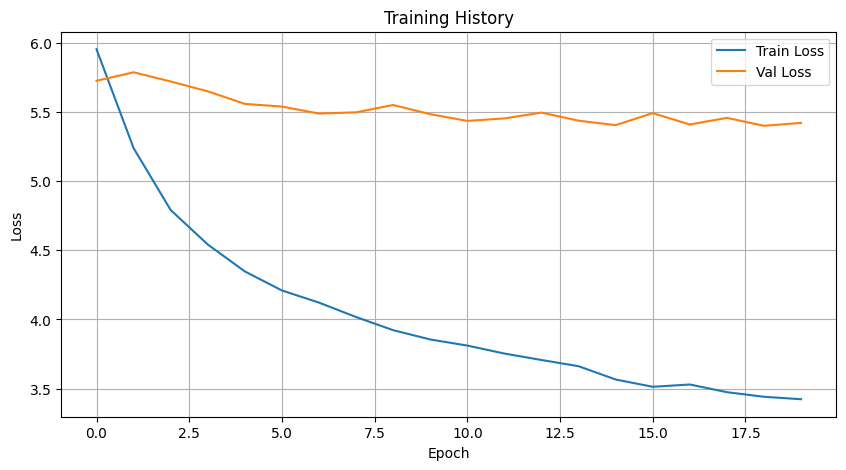

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_history, label='Train Loss')
plt.plot(valid_history, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training History')
plt.legend()
plt.grid(True)
plt.show()

__Let's take a look at our network quality__:

In [49]:
import math

class PositionalEncoding(nn.Module):
    def __init__(self, emb_dim, dropout=0.1, max_len=512):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, emb_dim)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, emb_dim, 2).float() * (-math.log(10000.0) / emb_dim)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(1)  # [max_len, 1, emb_dim]
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0)]
        return self.dropout(x)


class TransformerEncoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, n_heads, n_layers, dropout, dec_n_layers):
        super().__init__()
        self.dec_n_layers = dec_n_layers
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.pos_encoding = PositionalEncoding(emb_dim, dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_dim,
            nhead=n_heads,
            dim_feedforward=hid_dim,
            dropout=dropout,
            batch_first=False
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.fc = nn.Linear(emb_dim, hid_dim)
        # Проекции для инициализации hidden и cell декодера
        self.fc_hidden = nn.Linear(hid_dim, hid_dim)
        self.fc_cell = nn.Linear(hid_dim, hid_dim)

    def forward(self, src):
        src_key_padding_mask = (src == PAD_IDX).transpose(0, 1)

        embedded = self.pos_encoding(self.embedding(src) * math.sqrt(self.embedding.embedding_dim))

        outputs = self.transformer(embedded, src_key_padding_mask=src_key_padding_mask)

        outputs = self.fc(outputs)
        # [seq_len, batch_size, hid_dim]

        # Среднее по последовательности для инициализации декодера
        mean_output = outputs.mean(dim=0)  # [batch_size, hid_dim]
        hidden = torch.tanh(self.fc_hidden(mean_output)).unsqueeze(0).repeat(self.dec_n_layers, 1, 1)
        cell = torch.tanh(self.fc_cell(mean_output)).unsqueeze(0).repeat(self.dec_n_layers, 1, 1)

        return outputs, hidden, cell


In [62]:
EMB_DIM = 256
HID_DIM = 512
N_LAYERS = 2
N_HEADS = 4
DEC_DROPOUT = 0.3

attn = Attention(HID_DIM)
enc = TransformerEncoder(
    vocab_size=VOCAB_SIZE,
    emb_dim=EMB_DIM,
    hid_dim=HID_DIM,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    dropout=0.1,
    dec_n_layers=N_LAYERS
)
dec = Decoder(VOCAB_SIZE, EMB_DIM, HID_DIM, N_LAYERS, DEC_DROPOUT, attn)
model2 = Seq2Seq(enc, dec, device).to(device)

optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.0005, weight_decay=1e-4)
scheduler2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer2, mode="min", patience=3, factor=0.5
)


C:\Users\spectrmen\AppData\Local\Temp\ipykernel_5572\3933397504.py:41: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
c:\Users\spectrmen\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


In [63]:
N_EPOCHS = 20
best_valid_loss2 = float('inf')
train_history2 = []
valid_history2 = []
patience_counter = 0
PATIENCE = 4

for epoch in range(N_EPOCHS):
    start_time = time.time()

    train_loss = train_epoch(model2, train_loader, optimizer2, criterion)
    valid_loss = evaluate(model2, val_loader, criterion)

    scheduler2.step(valid_loss)

    if valid_loss < best_valid_loss2:
        best_valid_loss2 = valid_loss
        patience_counter = 0
        torch.save(model2.state_dict(), 'best_model2.pt')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping на эпохе {epoch+1}")
            break

    train_history2.append(train_loss)
    valid_history2.append(valid_loss)

    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1:02} | Time: {elapsed:.0f}s | "
          f"Train Loss: {train_loss:.3f} | "
          f"Val Loss: {valid_loss:.3f} | "
          f"Patience: {patience_counter}/{PATIENCE}")

Epoch 02 | Time: 369s | Train Loss: 5.507 | Val Loss: 5.738 | Patience: 0/4
Epoch 03 | Time: 361s | Train Loss: 5.159 | Val Loss: 5.637 | Patience: 0/4
Epoch 04 | Time: 360s | Train Loss: 4.929 | Val Loss: 5.586 | Patience: 0/4
Epoch 05 | Time: 364s | Train Loss: 4.770 | Val Loss: 5.500 | Patience: 0/4
Epoch 06 | Time: 357s | Train Loss: 4.655 | Val Loss: 5.492 | Patience: 0/4
Epoch 07 | Time: 354s | Train Loss: 4.574 | Val Loss: 5.471 | Patience: 0/4
Epoch 08 | Time: 355s | Train Loss: 4.496 | Val Loss: 5.402 | Patience: 0/4
Epoch 09 | Time: 358s | Train Loss: 4.435 | Val Loss: 5.417 | Patience: 1/4
Epoch 10 | Time: 357s | Train Loss: 4.361 | Val Loss: 5.420 | Patience: 2/4
Epoch 11 | Time: 354s | Train Loss: 4.310 | Val Loss: 5.373 | Patience: 0/4
Epoch 12 | Time: 357s | Train Loss: 4.260 | Val Loss: 5.358 | Patience: 0/4
Epoch 13 | Time: 360s | Train Loss: 4.206 | Val Loss: 5.340 | Patience: 0/4
Epoch 14 | Time: 356s | Train Loss: 4.164 | Val Loss: 5.310 | Patience: 0/4
Epoch 15 | T

In [59]:
print(f"Параметров: {count_parameters(model2):,}")

Параметров: 21,491,008


In [60]:
print(next(model2.parameters()).device)

cuda:0


In [52]:
model2.load_state_dict(torch.load('best_model2.pt'))
model2.eval()

original_text = []
generated_text = []

with torch.no_grad():
    for src, trg in tqdm.tqdm(test_loader):
        src, trg = src.to(device), trg.to(device)
        output = model2(src, trg, teacher_forcing_ratio=0)
        output = output.argmax(dim=-1)

        for i in range(trg.shape[1]):
            ref_ids = [t.item() for t in trg[:, i]
                       if t.item() not in [SOS_IDX, EOS_IDX, PAD_IDX]]
            hyp_ids = [t.item() for t in output[:, i]
                       if t.item() not in [SOS_IDX, EOS_IDX, PAD_IDX]]
            original_text.append([tokenizer.decode(ref_ids).split()])
            generated_text.append(tokenizer.decode(hyp_ids).split())

bleu = corpus_bleu(original_text, generated_text) * 100
print(f"BLEU: {bleu:.2f}")

100%|██████████| 20/20 [00:11<00:00,  1.72it/s]


BLEU: 1.57


In [54]:
model2.load_state_dict(torch.load('best_model2.pt'))
model2.eval()

src, trg = next(iter(test_loader))
src, trg = src.to(device), trg.to(device)

with torch.no_grad():
    output = model2(src, trg, teacher_forcing_ratio=0)
    output = output.argmax(dim=-1)

idx = 0
ref_ids = [t.item() for t in trg[:, idx]
           if t.item() not in [SOS_IDX, EOS_IDX, PAD_IDX]]
hyp_ids = [t.item() for t in output[:, idx]
           if t.item() not in [SOS_IDX, EOS_IDX, PAD_IDX]]

print(f"Reference: {tokenizer.decode(ref_ids)}")
print(f"Generated: {tokenizer.decode(hyp_ids)}")

Reference:  There is a full kitchen with an oven and a refrigerator.
Generated:  The rooms a a and and a and and a..............


In [55]:
print("Reference:", original_text[0])
print("Generated:", generated_text[0])

Reference: [['There', 'is', 'a', 'full', 'kitchen', 'with', 'an', 'oven', 'and', 'a', 'refrigerator.']]
Generated: ['The', 'rooms', 'a', 'a', 'and', 'and', 'a', 'and', 'and', 'a..............']


In [ ]:
original_text = []
generated_text = []
model.eval()
with torch.no_grad():

    for i, batch in tqdm.tqdm(enumerate(test_iterator)):

        src = batch.src
        trg = batch.trg

        output = model(src, trg, 0) #turn off teacher forcing

        #trg = [trg sent len, batch size]
        #output = [trg sent len, batch size, output dim]

        output = output.argmax(dim=-1)

        original_text.extend([get_text(x, TRG.vocab) for x in trg.cpu().numpy().T])
        generated_text.extend([get_text(x, TRG.vocab) for x in output[1:].detach().cpu().numpy().T])

# original_text = flatten(original_text)
# generated_text = flatten(generated_text)

59it [00:03, 18.87it/s]


In [ ]:
corpus_bleu([[text] for text in original_text], generated_text) * 100

14.139920232081806